In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_csv("/Users/somtochukwunwankwo/Downloads/medical_examination.csv")

In [7]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [89]:
df["overweight"]=(df["weight"] / ((df["height"]/100)**2)  >25).astype(int)

In [91]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,Overweight,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0,0


In [41]:
df[["cholesterol","gluc"]]=(df[["cholesterol","gluc"]] >1).astype(int)

In [43]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,Overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0


In [85]:
def draw_cat_plot(data):
    
    sns.catplot(data=data,kind='box');
    

In [101]:
df_cat=pd.melt(df,id_vars=['cardio'],value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'])

In [103]:
df_cat

,cardio,variable,value
0,0,cholesterol,0
1,1,cholesterol,1
2,1,cholesterol,1
3,1,cholesterol,0
4,0,cholesterol,0
...,...,...,...
419995,0,overweight,1
419996,1,overweight,1
419997,1,overweight,1
419998,1,overweight,1


In [105]:
df_cat_grouped = df_cat.groupby(['cardio', 'variable', 'value']) 

In [115]:
df_cat_grouped = df_cat.groupby(['cardio', 'variable', 'value']) \
                       .size() \
                       .reset_index(name='total')


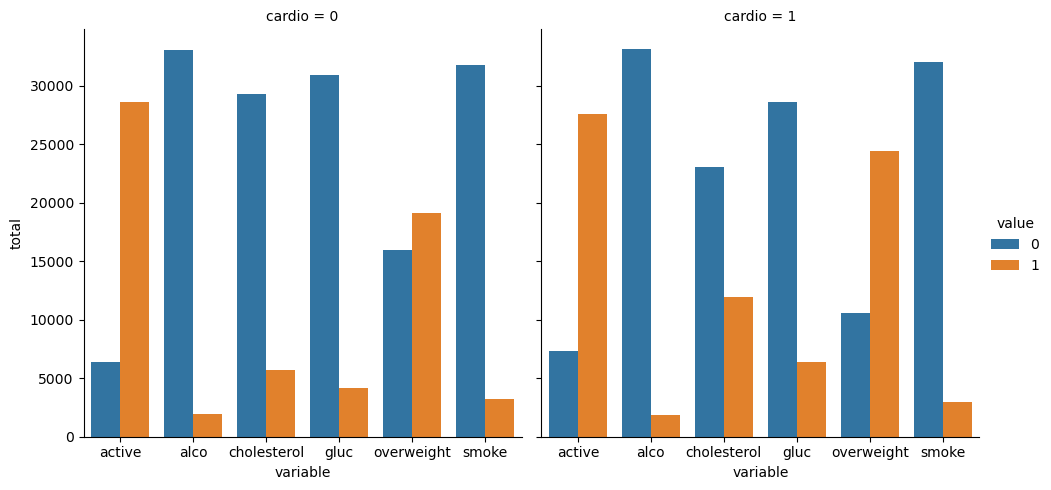

In [135]:
cat_plot=sns.catplot(df_cat_grouped, x='variable',
    y='total',
    hue='value',
    col='cardio',
    kind='bar');

In [125]:
df_cat_grouped

,cardio,variable,value,total
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


In [137]:
fig = cat_plot.fig

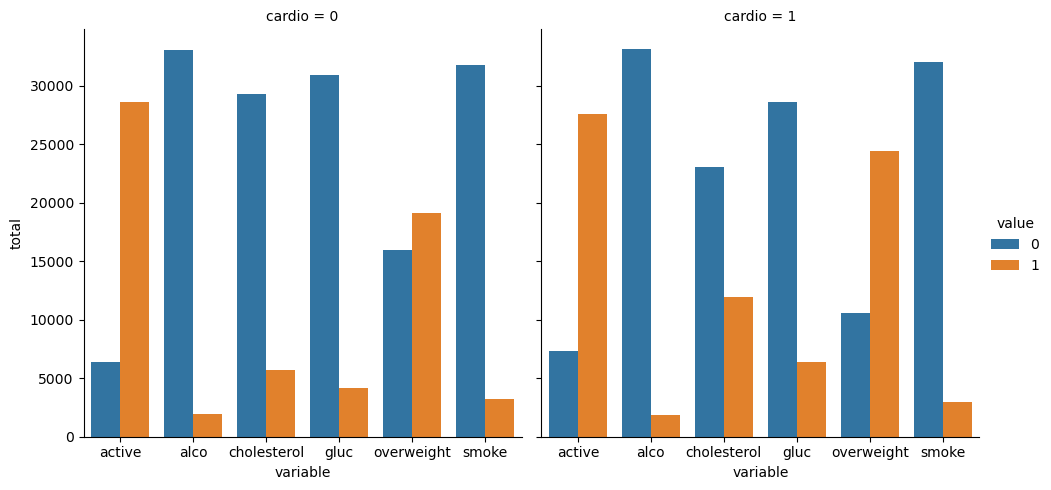

In [139]:
fig

In [143]:
def heat_map():
    sns.heatmap(df_heat)

In [ ]:
Clean the data in the df_heat variable by filtering out the following patient segments that represent incorrect data:
diastolic pressure is higher than systolic (Keep the correct data with (df['ap_lo'] <= df['ap_hi']))
height is less than the 2.5th percentile ( Keep the correct data with (df['height'] >= df['height'].quantile(0.025)))
height is more than the 97.5th percentile
weight is less than the 2.5th percentile
weight is more than the 97.5th percentile

In [151]:
mask_dia= df['ap_lo'] <= df['ap_hi']
low,high=df['height'].quantile([0.025, 0.975])
mask_height= df['height'].between(low, high)
low,high=df['weight'].quantile([0.025, 0.975])
mask_weight= df['weight'].between(low, high)

df_heat=df[mask_dia & mask_height& mask_weight]


In [177]:
corr=df_heat.corr()

In [179]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

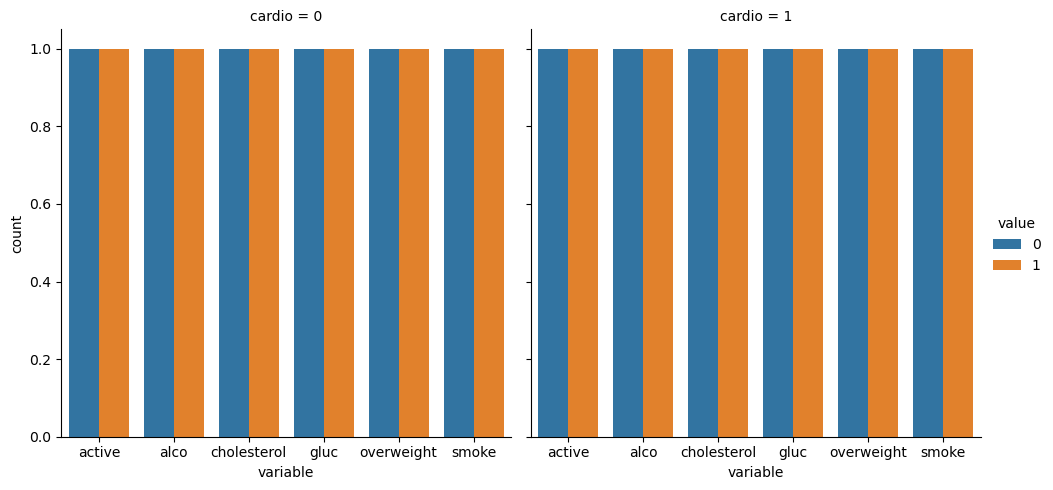

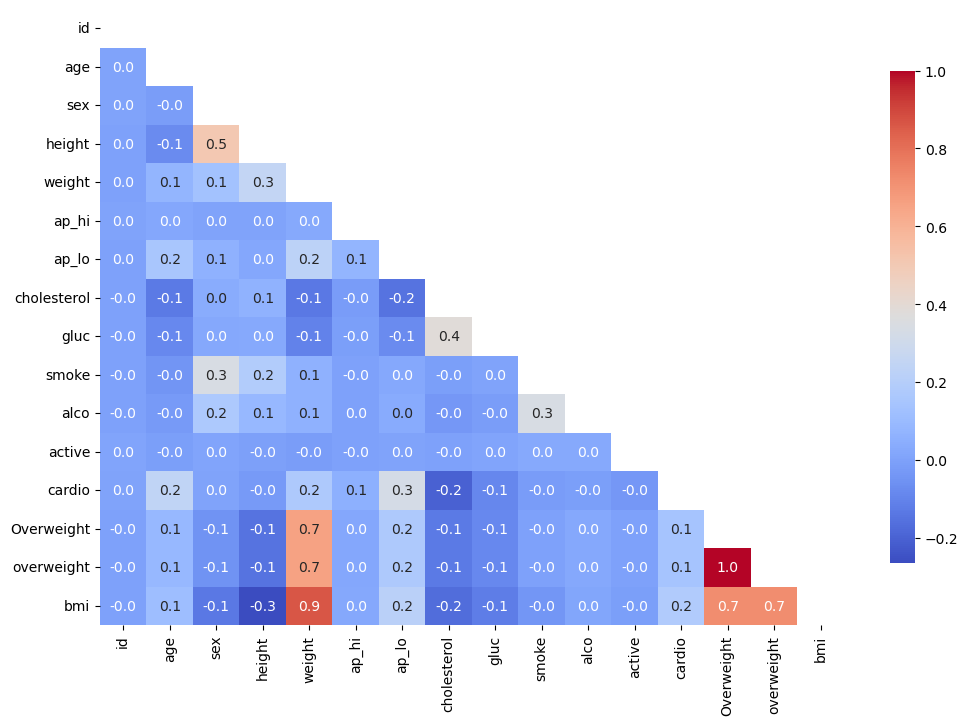

In [185]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the data


# Add overweight column based on BMI calculation
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2
df['overweight'] = df['bmi'].apply(lambda x: 1 if x > 25 else 0)

# Normalize cholesterol and gluc values
df['cholesterol'] = df['cholesterol'].apply(lambda x: 0 if x == 1 else 1)
df['gluc'] = df['gluc'].apply(lambda x: 0 if x == 1 else 1)

# Create a DataFrame for categorical plot
df_cat = pd.melt(df, id_vars=['cardio'], value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'])

# Group and reformat the data
df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='count')

# Draw the categorical plot
fig = sns.catplot(x='variable', hue='value', col='cardio', data=df_cat, kind='count').fig

# Clean the data for the heat map
df_heat = df[(df['ap_lo'] <= df['ap_hi']) &
             (df['height'] >= df['height'].quantile(0.025)) &
             (df['height'] <= df['height'].quantile(0.975)) &
             (df['weight'] >= df['weight'].quantile(0.025)) &
             (df['weight'] <= df['weight'].quantile(0.975))]

# Calculate the correlation matrix
corr = df_heat.corr()

# Generate the mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Plot the heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'shrink': .8})

# Store the figure
fig_heatmap = plt.gcf()

# Show the figure
plt.show()

In [181]:
mask

array([[False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, Fa

In [187]:
df_heat = df[(df['ap_lo'] <= df['ap_hi']) &
             (df['height'] >= df['height'].quantile(0.025)) &
             (df['height'] <= df['height'].quantile(0.975)) &
             (df['weight'] >= df['weight'].quantile(0.025)) &
             (df['weight'] <= df['weight'].quantile(0.975))]

In [191]:
corr=df_heat.corr()

In [193]:
corr

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,Overweight,overweight,bmi
id,1.000000,0.002507,0.003426,0.000326,0.000149,0.003492,0.000484,-0.003719,-0.002289,-0.002732,-0.000708,0.005891,0.003900,-0.000679,-0.000679,-0.000025
age,0.002507,1.000000,-0.018132,-0.076932,0.070168,0.018689,0.153508,-0.129996,-0.086990,-0.044371,-0.026970,-0.011445,0.240241,0.089573,0.089573,0.110267
sex,0.003426,-0.018132,1.000000,0.505785,0.129979,0.005063,0.059947,0.037605,0.021357,0.337436,0.168637,0.007864,0.002320,-0.052930,-0.052930,-0.135588
height,0.000326,-0.076932,0.505785,1.000000,0.251503,0.004586,0.017922,0.063522,0.030469,0.187830,0.089785,-0.005661,-0.024102,-0.149570,-0.149570,-0.266305
weight,0.000149,0.070168,0.129979,0.251503,1.000000,0.027030,0.227922,-0.135981,-0.107072,0.056533,0.059917,-0.014430,0.170042,0.655926,0.655926,0.862657
ap_hi,0.003492,0.018689,0.005063,0.004586,0.027030,1.000000,0.072803,-0.022807,-0.011111,-0.001928,0.000769,-0.000222,0.050556,0.017327,0.017327,0.024925
ap_lo,0.000484,0.153508,0.059947,0.017922,0.227922,0.072803,1.000000,-0.150362,-0.074840,0.023275,0.033042,0.001569,0.327181,0.172212,0.172212,0.216786
cholesterol,-0.003719,-0.129996,0.037605,0.063522,-0.135981,-0.022807,-0.150362,1.000000,0.383743,-0.012680,-0.038446,-0.002494,-0.203467,-0.127986,-0.127986,-0.167416
gluc,-0.002289,-0.086990,0.021357,0.030469,-0.107072,-0.011111,-0.074840,0.383743,1.000000,0.004157,-0.014297,0.010145,-0.088445,-0.088109,-0.088109,-0.121930
smoke,-0.002732,-0.044371,0.337436,0.187830,0.056533,-0.001928,0.023275,-0.012680,0.004157,1.000000,0.341200,0.026940,-0.020345,-0.003274,-0.003274,-0.041652


In [205]:
df_heat.info()


<class 'pandas.core.frame.DataFrame'>
Index: 63259 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           63259 non-null  int64  
 1   age          63259 non-null  int64  
 2   sex          63259 non-null  int64  
 3   height       63259 non-null  int64  
 4   weight       63259 non-null  float64
 5   ap_hi        63259 non-null  int64  
 6   ap_lo        63259 non-null  int64  
 7   cholesterol  63259 non-null  int64  
 8   gluc         63259 non-null  int64  
 9   smoke        63259 non-null  int64  
 10  alco         63259 non-null  int64  
 11  active       63259 non-null  int64  
 12  cardio       63259 non-null  int64  
 13  Overweight   63259 non-null  int64  
 14  overweight   63259 non-null  int64  
 15  bmi          63259 non-null  float64
dtypes: float64(2), int64(14)
memory usage: 8.2 MB
